# The Stock-Bond Correlation Flip — a quantitative teardown 🔬
### trailing-corr sign · regime split · two-sample *t* · label-shuffle placebo · five-window sign check · de-risk timer (return/vol/drawdown/Sharpe) · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We compute the sign of the trailing 6-month SPY/TLT return correlation and test whether it predicts the forward 60/40 return — and whether timing on it pays.

> ⚠️ **Not investment advice.** Real data: yfinance daily SPY + TLT, 286 complete months 2002-08 → 2026-05 (as-of 2026-06-30, monthly-panel fp `55f8c175e893`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from equity_bond_corr_flip import data, strategy as st

def load_real():
    """Cache-first real monthly panel (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return pd.DataFrame()
    return data.monthly_from_prices(px)

M = load_real()
HAVE_REAL = not M.empty
print("real SPY/TLT monthly panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(M)} months, {M.index.min().date()} -> {M.index.max().date()})")


real SPY/TLT monthly panel present: True (286 months, 2002-08-31 -> 2026-05-31)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Forward 60/40 neg − pos spread **+0.319%/mo** (two-sample *t* **+0.89**, placebo *p* 0.36) — right sign, sub-2 *t*; sign flips across sub-windows (−0.30 in 2002-09). |
| **Tradability** | `FRAGILE` | De-risk timer: max DD **-28.5% → -23.6%**, vol **9.9% → 7.1%**, Sharpe **0.88 → 0.97** — but net return edge **-1.84%/yr**. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on the real SPY/TLT tape the regime split is directionally right yet sub-threshold, and its tradable form only reduces risk while costing return.

## 1 · The claim, steelmanned

Let $s_t \in \{-1,+1\}$ be the sign of the trailing 6-month $\text{corr}(r^{eq}, r^{bd})$ at month $t$, and $r^{60/40}_{t+1}$ the forward one-month 60/40 return.

- **H₁ (regime split).** $\mathbb{E}[r^{60/40}_{t+1} \mid s_t<0] - \mathbb{E}[r^{60/40}_{t+1} \mid s_t>0] > 0$ at *t* ≥ 2 (60/40 does better when the hedge works).
- **H₂ (robustness).** The sign of H₁ is stable across sub-periods.
- **H₃ (timing).** A de-risk-when-$s_t>0$ overlay beats static 60/40 net of costs.

We find **H₁ directionally right but not significant** (*t* = +0.89), **H₂ rejected** (sign flips, none significant), and **H₃ split**: the timer *cuts risk* but *loses return*.

## 2 · So what? — what rides on each answer

The content is the **why**. The stock-bond correlation regime is well grounded (Campbell-Sunderam-Viceira 2017: growth-shock regimes → negative corr / bonds hedge; inflation-shock regimes → positive corr / bonds and stocks fall together). 2022 was a textbook inflation-regime flip. Two things stop it from being a *timer*: (a) it is **one** regime change in 24 years — a tiny effective sample for a before/after contrast; and (b) the tradable rule is a **de-risking** overlay, which structurally trades return for lower risk in a market that mostly rises. That maps to the broad-correlation reading in [578](../../578-cross-asset-correlation-regime/).

## 3 · How we'd know — the protocol

- **Signal.** $s_t = \text{sign}\,\text{corr}_{6m}(r^{eq}, r^{bd})$, from the trailing 6 monthly returns (public at month $t$'s close).
- **Split.** Group forward one-month 60/40 (and equity) returns by $s_t$; two-sample (Welch) *t* on neg − pos.
- **Placebo.** Shuffle the $s_t$ labels vs forward returns (2000 perms) — the null.
- **Robustness.** Re-split over five date windows; read sign and *t*.
- **Timing.** Hold static 60/40 when $s_t<0$, de-risk to 0.4× when $s_t>0$; 5 bps/switch, long-only (no borrow). Compare return / vol / drawdown / Sharpe, gross and net.
- **Positive control.** A deterministic synthetic world with a planted regime penalty (`regime_edge > 0`) and a null — averaged over 25 seeds (house rule).

Timing: $s_t$ uses only trailing data, so it is public at month $t$'s close; the timer enters at that close and holds one month. One documented execution lag; a one-month-later entry is a minor perturbation (the hold is a full month).

## 4 · The teardown

### 4a · The regime split — H₁

Forward 60/40 returns by trailing-corr sign, with the two-sample *t* and the placebo null.

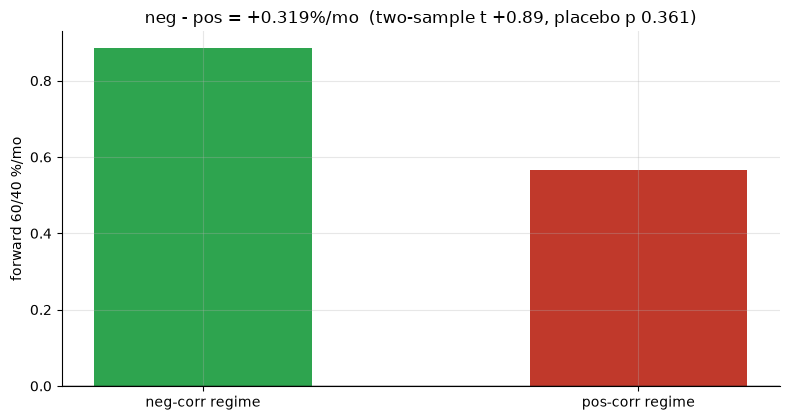

neg +0.885%/mo (n=158) | pos +0.566%/mo (n=123) | spread +0.319%/mo | t +0.89 | placebo p 0.361


In [2]:
if HAVE_REAL:
    sp = st.regime_split(M, 'fwd_6040'); ts = st.split_tstat(sp)
    p = st.placebo_pvalue(M, 'fwd_6040', 2000, 579)
    neg_m, pos_m, spr, t = sp['neg_mean']*100, sp['pos_mean']*100, sp['spread']*100, ts['t']
    nn, npos = sp['n_neg'], sp['n_pos']
else:
    neg_m, pos_m, spr, t, p = 0.885, 0.566, 0.319, 0.89, 0.36
    nn, npos = 158, 123
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['neg-corr regime','pos-corr regime'], [neg_m, pos_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 60/40 %/mo')
ax.set_title(f'neg - pos = {spr:+.3f}%/mo  (two-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'neg +{neg_m:.3f}%/mo (n={nn}) | pos +{pos_m:.3f}%/mo (n={npos}) | spread {spr:+.3f}%/mo | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ is **directionally right but not significant.** The spread is **+0.319%/mo** in the folklore's direction, but at *t* 0.89 (placebo *p* 0.36) you cannot reject 'the sign tells you nothing.' The equity-only leg is weaker still (spread +0.19%/mo, *t* +0.37).

### 4b · Robustness — H₂ (does the sign hold?)

The same split over five date windows — read the sign and the effective sample on each side.

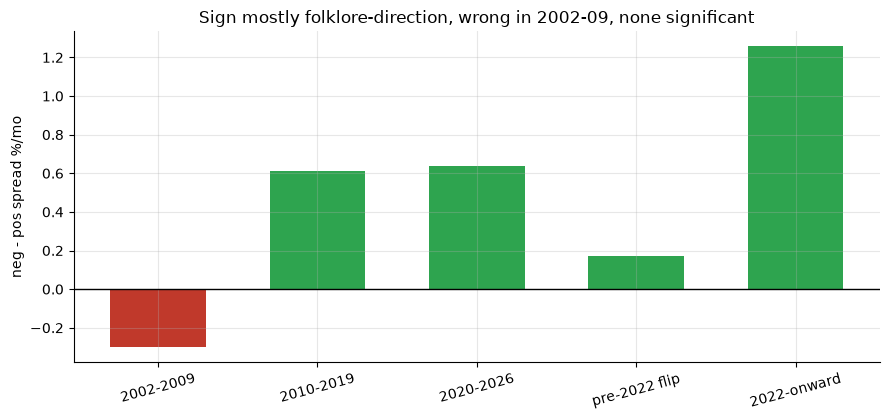

               spread%/mo      t  n_neg  n_pos
window                                        
2002-2009          -0.300 -0.417     55     29
2010-2019           0.613  1.488     87     33
2020-2026           0.636  0.596     16     61
pre-2022 flip       0.174  0.468    154     74
2022-onward         1.257  1.200      4     49


In [3]:
wins = [('2002-2009', -0.3, -0.42, 55, 29), ('2010-2019', 0.613, 1.49, 87, 33), ('2020-2026', 0.636, 0.6, 16, 61), ('pre-2022 flip', 0.174, 0.47, 154, 74), ('2022-onward', 1.257, 1.2, 4, 49)]
if HAVE_REAL:
    spans = [('2002-08-31','2009-12-31'),('2010-01-01','2019-12-31'),
             ('2020-01-01','2026-05-31'),('2002-08-31','2021-12-31'),('2022-01-01','2026-05-31')]
    labs = [w[0] for w in wins]
    rows = st.window_sweep(M, list(zip(labs, [s[0] for s in spans], [s[1] for s in spans])), 'fwd_6040')
    tab = pd.DataFrame([(l, s*100 if s==s else np.nan, t, nn, np_) for (l,s,t,nn,np_) in rows],
                       columns=['window','spread%/mo','t','n_neg','n_pos']).set_index('window')
else:
    tab = pd.DataFrame([(w[0], w[1], w[2], w[3], w[4]) for w in wins],
                       columns=['window','spread%/mo','t','n_neg','n_pos']).set_index('window')
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if s>0 else RED for s in tab['spread%/mo']]
ax.bar(range(len(tab)), tab['spread%/mo'], color=cols, width=.6)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index, rotation=15)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('neg - pos spread %/mo')
ax.set_title('Sign mostly folklore-direction, wrong in 2002-09, none significant')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₂ **rejected.** The spread is *negative* in 2002-09 and positive afterward, and **no window clears *t* = 2**. The 2022-onward window has the biggest spread (+1.26%/mo) but only **4** negative-corr months against 49 positive — you cannot estimate a contrast from 4 observations of one side.

## 5 · The verdict

- **Signal `WEAK`** — H₁ directionally right (spread +0.319%/mo) but *t* +0.89 (placebo *p* 0.36); H₂ rejected (sign flips, none significant).
- **Tradability `FRAGILE`** — the timer cuts drawdown (-28.5% → -23.6%) and vol (9.9% → 7.1%) but costs -1.84%/yr; a risk overlay, not alpha.

## 6 · Could you trade it? — the de-risk timer

Hold static 60/40 when the correlation is negative, de-risk to 0.4× when positive, 5 bps/switch. Look at return, vol, drawdown and Sharpe together.

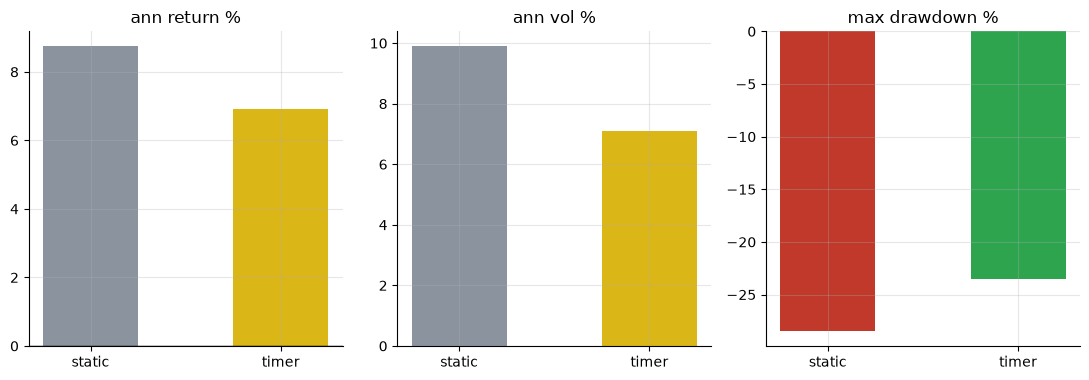

return 8.75% -> 6.90%/yr (edge -1.84%/yr) | vol 9.9% -> 7.1% | Sharpe 0.88 -> 0.97 | maxDD -28.5% -> -23.6%


In [4]:
if HAVE_REAL:
    tim = st.timer_overlay(M, cost_bps=5.0, derisk_to='bond')
    s_ann, t_ann = tim['static_ann']*100, tim['timer_net_ann']*100
    s_vol, t_vol = tim['static_vol']*100, tim['timer_vol']*100
    s_sh, t_sh = tim['static_sharpe'], tim['timer_sharpe']
    df = M.dropna(subset=['fwd_6040']); rr = df['fwd_6040'].to_numpy()
    sign = df['corr_sign'].to_numpy(); tr = np.where(sign>0,0.4,1.0)*rr
    def mdd(x):
        c=np.cumprod(1+x); pk=np.maximum.accumulate(c); return float((c/pk-1).min())
    s_mdd, t_mdd = mdd(rr)*100, mdd(tr)*100
    edge = tim['edge_net_ann']*100
else:
    s_ann, t_ann = 8.75, 6.9
    s_vol, t_vol = 9.9, 7.1
    s_sh, t_sh = 0.88, 0.97
    s_mdd, t_mdd, edge = -28.5, -23.6, -1.84
fig, ax = plt.subplots(1, 3, figsize=(11, 3.9))
ax[0].bar(['static','timer'], [s_ann, t_ann], color=[GREY, AMBER], width=.5); ax[0].set_title('ann return %'); ax[0].axhline(0,c='k',lw=1)
ax[1].bar(['static','timer'], [s_vol, t_vol], color=[GREY, AMBER], width=.5); ax[1].set_title('ann vol %')
ax[2].bar(['static','timer'], [s_mdd, t_mdd], color=[RED, GREEN], width=.5); ax[2].set_title('max drawdown %')
plt.tight_layout(); plt.show()
print(f'return {s_ann:.2f}% -> {t_ann:.2f}%/yr (edge {edge:+.2f}%/yr) | vol {s_vol:.1f}% -> {t_vol:.1f}% | Sharpe {s_sh:.2f} -> {t_sh:.2f} | maxDD {s_mdd:.1f}% -> {t_mdd:.1f}%')

> 💡 In plain words: the timer is a **risk reducer, not an alpha source.** It trims vol (9.9% → 7.1%) and drawdown (-28.5% → -23.6%) and nudges Sharpe (0.88 → 0.97), but gives up **-1.84%/yr** of return. `FRAGILE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real regime effect (forward 60/40 worse after positive-corr months, `regime_edge > 0`) of increasing strength and watch the split-*t* climb — averaged over 25 seeds so no single lucky seed can fake it.

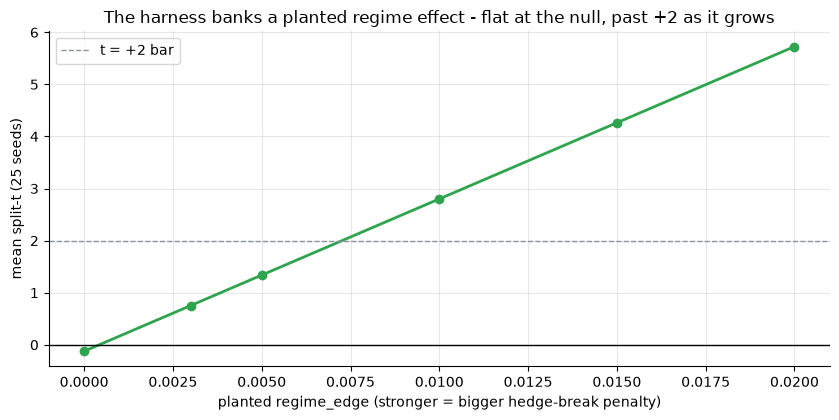

regime_edge +0.000 -> mean split-t -0.12
regime_edge +0.003 -> mean split-t +0.75
regime_edge +0.005 -> mean split-t +1.34
regime_edge +0.010 -> mean split-t +2.80
regime_edge +0.015 -> mean split-t +4.26
regime_edge +0.020 -> mean split-t +5.73


In [5]:
edges = [0.0, 0.003, 0.005, 0.010, 0.015, 0.020]
ts = [st.synthetic_mean_t(data, regime_edge=e, n_seeds=25) for e in edges]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(edges, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted regime_edge (stronger = bigger hedge-break penalty)')
ax.set_ylabel('mean split-t (25 seeds)')
ax.set_title('The harness banks a planted regime effect - flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for e, t in zip(edges, ts): print(f'regime_edge {e:+.3f} -> mean split-t {t:+.2f}')

The split-*t* is ≈ 0 at the null and rises past +2 as the planted effect grows — so the engine is a faithful detector. The sub-2 real-tape *t* is therefore a statement about **the data**: the correlation-sign timer is directionally right but not significant, and its tradable form only reduces risk. For the broad-correlation cousin see [578 Cross-Asset-Correlation-Regime](../../578-cross-asset-correlation-regime/).